# YogAI - Chair Pose Experiment
**Comparative ML Study: Logistic Regression vs SVC vs KNN vs XGBoost**

This notebook runs the full hyperparameter search, cross-validation, and
inference latency benchmark for the **Chair Pose** classifier.

All artifacts (pipeline, label encoder, class map, metadata) are saved to
the working directory so they can be loaded directly during real-video inference.


### Notebook Structure
1. Environment setup & imports  
2. Configuration - Chair Pose  
3. Data loading & validation  
4. Exploratory checks (class balance, feature stats)  
5. Experiment loop - all 4 models  
6. Results & benchmark table  
7. Artifact verification  
8. Inference smoke-test (load saved artifacts & predict one sample)


## 1. Environment Setup

In [32]:
# Install dependencies if running for the first time
# Comment out after first run
import subprocess, sys

packages = ["scikit-learn", "xgboost", "pandas", "numpy", "matplotlib",
            "seaborn", "joblib", "pyyaml"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All dependencies ready.")

All dependencies ready.


In [2]:
import sys
import json
import time
import math
import warnings
import logging
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, GroupKFold,StratifiedGroupKFold,
    train_test_split,
)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

#  Add src/ to path so we can import project modules 
NOTEBOOK_DIR = Path(".").resolve()

# Go up from src/models/training -> project root
PROJECT_ROOT = NOTEBOOK_DIR.parents[2]

SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR))

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

print(f"Working directory : {NOTEBOOK_DIR}")
print(f"src/ on path      : {SRC_DIR.exists()}")

Working directory : D:\YogAi_Models_Refactor\src\models\training
src/ on path      : True


## 2. Configuration - Warrior2 Pose

In [29]:
#  Pose identity 
POSE_NAME = "chair_pose"

# Path to the chair pose CSV
# Update this to your actual file path if it differs
CSV_PATH = Path("../../../data/processed/engineered_features/chair_pose/chair_pose_features.csv")


#  Feature columns (must match CSV headers exactly) 
FEATURE_COLUMNS = [
    "camera_knee_flexion_angle",
    "camera_torso_hip_knee_angle",
    "camera_shoulder_arm_angle",
    "camera_wrist_shoulder_vertical_delta",
    "camera_hip_knee_vertical_delta",
    "camera_shoulder_ankle_horizontal_offset",
    "camera_knee_ankle_horizontal_overhang",

]

LABEL_COLUMN    = "label"
SOURCE_ID_COL   = "source_id"        # same value for all frames from one video
FRAME_NUMBER_COL = "frame_number"

#  Cross-validation settings 
CV_CONFIG = {
    "n_splits"   : 5,
    # "n_splits"   : 2,
    "random_seed": 42,
    "scoring"    : "f1_weighted",
    "n_jobs"     : -1,
}

#  Hyperparameter grids 
# KNN NOTE: n_neighbors must never exceed floor(sqrt(n_training_samples)).
# A runtime warning is raised below if any value violates this.
HYPERPARAMETER_GRIDS = {
    "logistic_regression": {
        "classifier__C"           : [0.01, 0.1, 1.0, 10.0, 100.0],
        "classifier__penalty"     : ["elasticnet"],
        "classifier__solver"      : ["saga"],  # 'saga' solver is required for elasticnet
        "classifier__l1_ratio"    : [0.2, 0.5, 0.8], # Ratio of L1 vs L2 regularization
        "classifier__class_weight": ["balanced"], # Fixes class imbalance
        "classifier__max_iter"    : [2000], # Saga requires more iterations to converge
    },
    "svc": {
        "classifier__C"     : [0.1, 1.0, 10.0, 100.0],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma" : ["scale", "auto"],
        "classifier__class_weight": [None, "balanced"],
    },
    "knn": {
        "classifier__n_neighbors": [3, 5, 7, 11, 15],
        "classifier__weights"    : ["uniform", "distance"],
        "classifier__metric"     : ["euclidean", "manhattan"],
    },

    "xgboost": {
        "classifier__n_estimators"    : [100, 150, 200],
        "classifier__max_depth"       : [3, 4, 5, 7], # Lower depth prevents complex over-fitting blocks
        "classifier__learning_rate"   : [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample"       : [0.6, 0.8, 1.0], # Row subsampling forces variance tolerance
        "classifier__colsample_bytree": [0.6, 0.8, 1.0],
        "classifier__min_child_weight": [1, 3, 5, 7], # Higher numbers stop trees from creating hyper-specific leaves
        "classifier__gamma"           : [0, 0.1, 0.2], # Minimum loss reduction required to make a split
    },

    # "xgboost": {
    #     "classifier__n_estimators"    : [100, 150, 200],
    #     "classifier__max_depth"       : [3, 4],       # Strictly low depth forces global rules instead of frame memorization
    #     "classifier__learning_rate"   : [0.01, 0.05, 0.1],
    #     "classifier__subsample"       : [0.6, 0.8],   # Subsampling prevents tree ensembling on exact clusters
    #     "classifier__colsample_bytree": [0.6, 0.8, 1.0],
    #     "classifier__min_child_weight": [3, 5, 7],     # Higher leaf size blocks hyper-specific partitions
    #     "classifier__gamma"           : [0.1, 0.2, 0.4], # Demands definitive loss reduction to split
    # },
}

XGBOOST_RANDOM_SEARCH_ITER = 30
LATENCY_WARMUP_CALLS       = 10
LATENCY_TRIAL_CALLS        = 500

print("Configuration loaded.")
print(f"Pose            : {POSE_NAME}")
print(f"Features        : {FEATURE_COLUMNS}")
print(f"CSV path        : {CSV_PATH}")
print(f"CSV exists      : {CSV_PATH.exists()}")

Configuration loaded.
Pose            : chair_pose
Features        : ['camera_knee_flexion_angle', 'camera_torso_hip_knee_angle', 'camera_shoulder_arm_angle', 'camera_wrist_shoulder_vertical_delta', 'camera_hip_knee_vertical_delta', 'camera_shoulder_ankle_horizontal_offset', 'camera_knee_ankle_horizontal_overhang']
CSV path        : ..\..\..\data\processed\engineered_features\chair_pose\chair_pose_features.csv
CSV exists      : True


In [4]:
#  Output folder structure 
# Root is created one level above the notebook file (.. folder)
# Structure:
#   ../chair_pose_files/
#       models/       — .joblib pipeline and label encoder files
#       metadata/     — .json class maps and metadata files
#       results/      — experiment summary CSV
#       images/       — confusion matrix and latency chart PNGs

NOTEBOOK_DIR  = Path(".").resolve()
OUTPUT_ROOT = NOTEBOOK_DIR.parent / "saved_files" / f"{POSE_NAME}_files"

DIR_MODELS    = OUTPUT_ROOT / "models"
DIR_METADATA  = OUTPUT_ROOT / "metadata"
DIR_RESULTS   = OUTPUT_ROOT / "results"
DIR_IMAGES    = OUTPUT_ROOT / "images"

for folder in [DIR_MODELS, DIR_METADATA, DIR_RESULTS, DIR_IMAGES]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Output root : {OUTPUT_ROOT}")
print(f"  models/   : {DIR_MODELS}")
print(f"  metadata/ : {DIR_METADATA}")
print(f"  results/  : {DIR_RESULTS}")
print(f"  images/   : {DIR_IMAGES}")

Output root : D:\YogAi_Models_Refactor\src\models\saved_files\chair_pose_files
  models/   : D:\YogAi_Models_Refactor\src\models\saved_files\chair_pose_files\models
  metadata/ : D:\YogAi_Models_Refactor\src\models\saved_files\chair_pose_files\metadata
  results/  : D:\YogAi_Models_Refactor\src\models\saved_files\chair_pose_files\results
  images/   : D:\YogAi_Models_Refactor\src\models\saved_files\chair_pose_files\images


## 3. Data Loading & Validation

In [5]:
#  Load CSV 
assert CSV_PATH.exists(), (
    f"CSV not found at '{CSV_PATH}'. "
    f"Update CSV_PATH in the Configuration cell above."
)

df = pd.read_csv(CSV_PATH)
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (2933, 11)


,source_id,label,frame_number,is_left_facing,camera_knee_flexion_angle,camera_torso_hip_knee_angle,camera_shoulder_arm_angle,camera_wrist_shoulder_vertical_delta,camera_hip_knee_vertical_delta,camera_shoulder_ankle_horizontal_offset,camera_knee_ankle_horizontal_overhang
0,bent_forward_1.mp4,bent_forward,6,0,117.700639,96.747273,168.870667,0.512931,0.467932,0.148474,0.162301
1,bent_forward_1.mp4,bent_forward,12,0,113.229238,100.030546,165.717620,0.555363,0.472851,0.250296,0.239367
2,bent_forward_1.mp4,bent_forward,18,0,112.990238,102.339328,163.633443,0.524548,0.456208,0.283297,0.252318
3,bent_forward_1.mp4,bent_forward,24,0,112.354021,103.225867,162.383647,0.494826,0.452958,0.309299,0.263954
4,bent_forward_1.mp4,bent_forward,30,0,117.182710,102.344016,163.137896,0.490874,0.453951,0.261225,0.207927


In [6]:
#  Validate required columns are present 
required_cols = FEATURE_COLUMNS + [LABEL_COLUMN, SOURCE_ID_COL]
missing_cols  = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(
        f"The following required columns are missing from the CSV: {missing_cols}\n"
        f"Available columns: {list(df.columns)}"
    )

print("All required columns present.")
print(f"\nColumn dtypes:")
print(df[required_cols].dtypes)

All required columns present.

Column dtypes:
camera_knee_flexion_angle                  float64
camera_torso_hip_knee_angle                float64
camera_shoulder_arm_angle                  float64
camera_wrist_shoulder_vertical_delta       float64
camera_hip_knee_vertical_delta             float64
camera_shoulder_ankle_horizontal_offset    float64
camera_knee_ankle_horizontal_overhang      float64
label                                          str
source_id                                      str
dtype: object


In [7]:
#  Check for nulls 
null_counts = df[required_cols].isnull().sum()
null_counts = null_counts[null_counts > 0]

if not null_counts.empty:
    print("WARNING: Null values detected:")
    print(null_counts)
    print("\nDropping rows with nulls...")
    df = df.dropna(subset=required_cols)
    print(f"Shape after dropping nulls: {df.shape}")
else:
    print("No null values. Dataset is clean.")

No null values. Dataset is clean.


In [8]:
#  Encode string labels to integers 
# LabelEncoder is fitted here on the full label set so all classes are known.
# The fitted encoder is saved as an artifact — inference must load and use
# this exact encoder to decode predictions back to strings.

label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(df[LABEL_COLUMN].str.lower().str.strip())

class_map = {idx: cls for idx, cls in enumerate(label_encoder.classes_)}
print("Label encoding:")
for k, v in class_map.items():
    count = (y_encoded == k).sum()
    print(f"  {k} -> '{v}'  ({count} samples, {count/len(y_encoded)*100:.1f}%)")

Label encoding:
  0 -> 'bent_forward'  (750 samples, 25.6%)
  1 -> 'correct'  (683 samples, 23.3%)
  2 -> 'dropped_arms'  (750 samples, 25.6%)
  3 -> 'shallow_squat'  (750 samples, 25.6%)


**Label encoding**:
  - 0 -> 'bent_forward'  (750 samples, 25.6%)
  - 1 -> 'correct'  (683 samples, 23.3%)
  - 2 -> 'dropped_arms'  (750 samples, 25.6%)
  - 3 -> 'shallow_squat'  (750 samples, 25.6%)

In [9]:
#  Extract X, y, groups 
X      = df[FEATURE_COLUMNS].values
y      = y_encoded
groups = df[SOURCE_ID_COL].values   # one group = one video source

n_unique_sources = len(np.unique(groups))
n_samples        = len(X)

print(f"\nDataset summary")
print(f"  Samples         : {n_samples}")
print(f"  Features        : {X.shape[1]}")
print(f"  Classes         : {len(class_map)}")
print(f"  Unique source_ids: {n_unique_sources}")
print(f"  (each source_id will stay entirely in train OR test - never split across both)")


Dataset summary
  Samples         : 2933
  Features        : 7
  Classes         : 4
  Unique source_ids: 69
  (each source_id will stay entirely in train OR test - never split across both)


In [ ]:
#  Experiment toggle — exclude bent_forward ─
# HYPOTHESIS: bent_forward and correct share overlapping feature distributions,
# causing the model to conflate the two classes. This experiment tests whether
# removing bent_forward improves correct's recall and overall model performance.
#
# Set to True to run the 4-class experiment (excluding bent_forward)
# Set to False to run the full 5-class experiment (default)

EXCLUDE_BENT_FORWARD = False   # <-- toggle here

#  Apply filter ─
if EXCLUDE_BENT_FORWARD:
    bent_forward_encoded = label_encoder.transform(["shallow_stance"])[0]
    keep_mask = y != bent_forward_encoded

    X      = X[keep_mask]
    y      = y[keep_mask]
    groups = groups[keep_mask]

    # Re-encode labels to consecutive integers (0,1,2,3) after dropping a class
    # - this prevents XGBoost from seeing a gap in class indices (0,1,3,4)
    # which would cause silent errors in num_class detection
    remaining_classes  = sorted(np.unique(y))
    remap              = {old: new for new, old in enumerate(remaining_classes)}
    y                  = np.array([remap[lbl] for lbl in y])

    # Rebuild class_map and refit label_encoder on remaining classes only
    remaining_names    = label_encoder.inverse_transform(remaining_classes)
    label_encoder      = LabelEncoder()
    label_encoder.fit(remaining_names)
    class_map          = {i: name for i, name in enumerate(remaining_names)}

    experiment_tag = "reduced_class"
    print("EXCLUDED: shallow_stance")
else:
    experiment_tag = "full_class"
    print("Running full class experiment.")

print(f"\nExperiment tag : {experiment_tag}")
print(f"Remaining classes ({len(class_map)}):")
for k, v in class_map.items():
    count = (y == k).sum()
    print(f"  {k} -> '{v}'  ({count} samples)")

Running full class experiment.

Experiment tag : full_class
Remaining classes (4):
  0 -> 'bent_forward'  (750 samples)
  1 -> 'correct'  (683 samples)
  2 -> 'dropped_arms'  (750 samples)
  3 -> 'shallow_squat'  (750 samples)


## 4. Exploratory Checks

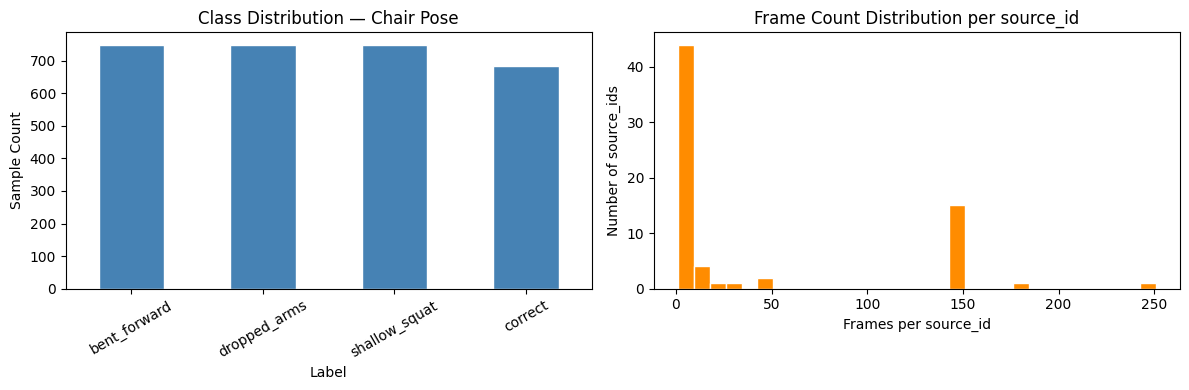

In [11]:
#  Class distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_strings = label_encoder.inverse_transform(y)
pd.Series(label_strings).value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Class Distribution — Chair Pose")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=30)

# Samples per source_id (frame count per video)
pd.Series(groups).value_counts().plot(
    kind="hist", bins=30, ax=axes[1], color="darkorange", edgecolor="white"
)
axes[1].set_title("Frame Count Distribution per source_id")
axes[1].set_xlabel("Frames per source_id")
axes[1].set_ylabel("Number of source_ids")

plt.tight_layout()
plt.show()

In [12]:
#  Feature statistics 
feature_df = pd.DataFrame(X, columns=FEATURE_COLUMNS)
feature_df.describe().round(4)

,camera_knee_flexion_angle,camera_torso_hip_knee_angle,camera_shoulder_arm_angle,camera_wrist_shoulder_vertical_delta,camera_hip_knee_vertical_delta,camera_shoulder_ankle_horizontal_offset,camera_knee_ankle_horizontal_overhang
count,2933.0000,2933.0000,2933.0000,2933.0000,2933.0000,2933.0000,2933.0000
mean,125.9806,121.2304,150.4856,0.5730,0.4599,0.1473,0.1986
std,14.1521,18.3357,27.9433,0.2229,0.1082,0.1370,0.0666
min,48.6517,8.2149,10.2258,0.0027,0.0595,0.0001,0.0025
25%,117.1271,108.4176,145.1514,0.4144,0.3775,0.0595,0.1607
50%,124.0670,117.0887,159.3346,0.5565,0.4681,0.1057,0.1916
75%,134.9004,135.2079,167.0681,0.7351,0.5302,0.1808,0.2299
max,172.4501,174.2675,179.5092,1.1518,0.8392,1.7987,1.4858


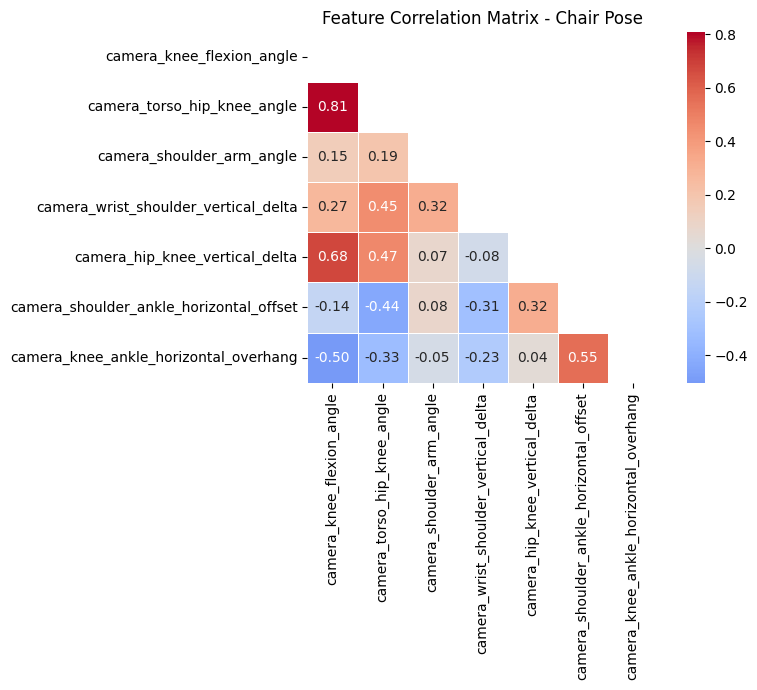

In [13]:
#  Feature correlation heatmap 
fig, ax = plt.subplots(figsize=(9, 7))
corr = feature_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax,
    linewidths=0.5, square=True,
)
ax.set_title("Feature Correlation Matrix - Chair Pose")
plt.tight_layout()
plt.show()

## 5. Experiment Helpers

In [ ]:
def build_pipeline(model_name: str) -> Pipeline:
    """
    Return an unfitted sklearn Pipeline: StandardScaler -> estimator.
    Must be unfitted when passed to GridSearchCV to prevent leakage.
    """
    seed = CV_CONFIG["random_seed"]

    estimators = {
        "logistic_regression": LogisticRegression(random_state=seed, max_iter=1000),
        "svc"                : SVC(random_state=seed, probability=True),
        "knn"                : KNeighborsClassifier(n_neighbors=5),
        "xgboost"            : XGBClassifier(
                                   random_state=seed,
                                   verbosity=0,
                                   eval_metric="mlogloss",
                               ),

    }

    if model_name not in estimators:
        raise ValueError(f"Unknown model '{model_name}'. Choose from {list(estimators)}")

    return Pipeline([
        ("scaler"    , StandardScaler()),
        ("classifier", estimators[model_name]),
    ])


def check_knn_neighbor_cap(n_neighbors_grid: list, n_training_samples: int) -> None:
    """Warn if any n_neighbors value exceeds floor(sqrt(n_training_samples))."""
    ceiling    = math.floor(math.sqrt(n_training_samples))
    oversized  = [k for k in n_neighbors_grid if k > ceiling]
    if oversized:
        warnings.warn(
            f"KNN grid has n_neighbors values {oversized} exceeding the "
            f"recommended ceiling floor(sqrt({n_training_samples})) = {ceiling}. "
            f"Consider trimming the grid.",
            UserWarning, stacklevel=2,
        )


def measure_inference_latency(
    pipeline, X_probe: np.ndarray,
    n_warmup: int = LATENCY_WARMUP_CALLS,
    n_trials: int = LATENCY_TRIAL_CALLS,
) -> dict:
    """
    Measure per-sample prediction latency.
    Warm-up calls are discarded to eliminate cold-start bias.
    p95/p99 are reported because real-time systems are bounded by tail latency.
    """
    for _ in range(n_warmup):
        pipeline.predict(X_probe)

    latencies_ms = np.empty(n_trials)
    for i in range(n_trials):
        t0 = time.perf_counter()
        pipeline.predict(X_probe)
        latencies_ms[i] = (time.perf_counter() - t0) * 1000.0

    return {
        "mean_ms"        : round(float(np.mean(latencies_ms)), 4),
        "std_ms"         : round(float(np.std(latencies_ms)), 4),
        "p95_ms"         : round(float(np.percentile(latencies_ms, 95)), 4),
        "p99_ms"         : round(float(np.percentile(latencies_ms, 99)), 4),
        "implied_max_fps": round(1000.0 / float(np.mean(latencies_ms)), 1),
    }

def load_results_from_disk(pose_name: str, experiment_tag: str, 
                            models: list, DIR_METADATA: Path) -> list:
    """
    Load experiment results from saved metadata JSONs.
    Use this to restore any experiment without re-running.
    """
    results = []
    
    for model_name in models:
        prefix    = f"{pose_name}_{experiment_tag}_{model_name}"
        meta_path = DIR_METADATA / f"{prefix}_metadata.json"
        
        if not meta_path.exists():
            print(f"[WARNING] Missing: {meta_path.name} — skipping")
            continue
            
        with open(meta_path) as f:
            results.append(json.load(f))
            
    print(f"Loaded {len(results)}/{len(models)} models "
          f"for '{pose_name}' — '{experiment_tag}'")
    return results


# Usage — load any experiment by just changing the tag
# all_results_4class = load_results_from_disk(
#     pose_name      = POSE_NAME,
#     experiment_tag = "4class_no_bent_forward",
#     models         = ["logistic_regression", "svc", "knn", "xgboost"],
#     DIR_METADATA   = DIR_METADATA,
# )

# After 5-class run, load that too the same way
# all_results_5class = load_results_from_disk(
#     pose_name      = POSE_NAME,
#     experiment_tag = "5class_full",
#     models         = ["logistic_regression", "svc", "knn", "xgboost"],
#     DIR_METADATA   = DIR_METADATA,
# )

print("Helper functions defined.")

Helper functions defined.


## 6. Train / Test Split

In [15]:
# from collections import defaultdict
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import StratifiedGroupKFold

# # 1. Initialize Seed
# seed = CV_CONFIG["random_seed"]
# rng  = np.random.default_rng(seed)

# # 2. Build a map: source_id -> majority class label 
# # (Each video/source_id maps to its primary class label to handle minor frame noise)
# source_to_label = {}
# for src in np.unique(groups):
#     mask = groups == src
#     majority_label = int(pd.Series(y[mask]).mode()[0])
#     source_to_label[src] = majority_label

# # 3. Group source_ids by their class for descriptive logging
# class_to_sources = defaultdict(list)
# for src, lbl in source_to_label.items():
#     class_to_sources[lbl].append(src)

# print("Source_ids per class:")
# for lbl, srcs in sorted(class_to_sources.items()):
#     print(f"  {class_map[lbl]}: {len(srcs)} source_ids")

# # 4. Stratified Group-Aware Train/Test Split
# # We use 5 splits (1/5 = 20%) to pull out a perfectly stratified, leak-free test track
# outer_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=seed)

# # Extract the indices for the first fold split
# train_idx, test_idx = next(outer_cv.split(X, y, groups=groups))

# # 5. Create clean, leak-free, class-balanced matrices
# X_train, X_test = X[train_idx], X[test_idx]
# y_train, y_test = y[train_idx], y[test_idx]
# groups_train    = groups[train_idx]

# # Extract distinct video paths/IDs for log tracking tracking
# train_sources = set(np.unique(groups_train))
# test_sources  = set(np.unique(groups[test_idx]))

# # 6. Verify and Print Split Metadata
# print(f"\nTrain: {len(X_train)} samples across {len(train_sources)} source_ids")
# print(f"Test : {len(X_test)} samples across {len(test_sources)} source_ids")

# print("\nTrain class distribution:")
# for k, v in class_map.items():
#     count = (y_train == k).sum()
#     print(f"  {v}: {count} ({count/len(y_train)*100:.1f}%)")

# print("\nTest class distribution:")
# for k, v in class_map.items():
#     count = (y_test == k).sum()
#     print(f"  {v}: {count} ({count/len(y_test)*100:.1f}%)")

In [16]:
from collections import defaultdict
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

# 1. Initialize Seed
seed = CV_CONFIG["random_seed"]
rng  = np.random.default_rng(seed)

# 2. Build a map: source_id -> majority class label 
source_to_label = {}
for src in np.unique(groups):
    mask = groups == src
    majority_label = int(pd.Series(y[mask]).mode()[0])
    source_to_label[src] = majority_label

# 3. Group source_ids by their class for descriptive logging
class_to_sources = defaultdict(list)
for src, lbl in source_to_label.items():
    class_to_sources[lbl].append(src)

print("Source_ids per class:")
for lbl, srcs in sorted(class_to_sources.items()):
    print(f"  {class_map[lbl]}: {len(srcs)} source_ids")

# 4. Stratified Group-Aware Train/Test Split
# 4-fold: minority classes have 5 source_ids → ~1 in test, ~4 in train
outer_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=seed)  # FIX 1: shuffle=True was missing

train_idx, test_idx = next(outer_cv.split(X, y, groups=groups))

# 5. Create clean, leak-free matrices
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train    = groups[train_idx]

train_sources = set(np.unique(groups_train))
test_sources  = set(np.unique(groups[test_idx]))

# FIX 2: Guard against empty minority class in test (1 source_id in test is fragile)
missing_in_test = set(class_map.keys()) - set(np.unique(y_test))
if missing_in_test:
    raise ValueError(
        f"Test set missing classes: {[class_map[c] for c in missing_in_test]}. "
        f"Try a different random_seed in CV_CONFIG."
    )

# 6. Verify and Print Split Metadata
print(f"\nTrain: {len(X_train)} samples across {len(train_sources)} source_ids")
print(f"Test : {len(X_test)} samples across {len(test_sources)} source_ids")

print("\nTrain class distribution:")
for k, v in class_map.items():
    count = (y_train == k).sum()
    print(f"  {v}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nTest class distribution:")
for k, v in class_map.items():
    count = (y_test == k).sum()
    print(f"  {v}: {count} ({count/len(y_test)*100:.1f}%)")

Source_ids per class:
  bent_forward: 5 source_ids
  correct: 54 source_ids
  dropped_arms: 5 source_ids
  shallow_squat: 5 source_ids

Train: 2232 samples across 65 source_ids
Test : 701 samples across 4 source_ids

Train class distribution:
  bent_forward: 600 (26.9%)
  correct: 432 (19.4%)
  dropped_arms: 600 (26.9%)
  shallow_squat: 600 (26.9%)

Test class distribution:
  bent_forward: 150 (21.4%)
  correct: 251 (35.8%)
  dropped_arms: 150 (21.4%)
  shallow_squat: 150 (21.4%)


In [17]:
#  Class balance assessment ─
train_counts = pd.Series(y_train).value_counts().sort_index()
max_count    = train_counts.max()
min_count    = train_counts.min()
imbalance_ratio = max_count / min_count

print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("Assessment: BALANCED — no resampling or class weighting needed.")
    print("Justification: ratio < 1.5, f1_weighted scoring already accounts")
    print("for minor differences in class support.")
elif imbalance_ratio < 3.0:
    print("Assessment: MILDLY IMBALANCED — consider class_weight='balanced'")
    print("for LogisticRegression and SVC.")
else:
    print("Assessment: IMBALANCED — add class_weight='balanced' to LR and SVC,")
    print("and set scale_pos_weight in XGBoost.")

Imbalance ratio (max/min): 1.39
Assessment: BALANCED — no resampling or class weighting needed.
Justification: ratio < 1.5, f1_weighted scoring already accounts
for minor differences in class support.


Finding suitable value of n_split

In [18]:
safe_n = None

for n_splits in [3, 4, 5]:
    print(f"\n{'='*40}")
    print(f"Testing n_splits = {n_splits}")
    print(f"{'='*40}")

    sgkf  = StratifiedGroupKFold(n_splits=n_splits)
    clean = True

    for fold_idx, (tr_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
        val_labels   = y_train[val_idx]
        class_counts = {class_map[k]: int((val_labels == k).sum()) for k in sorted(class_map)}
        zeros        = [cls for cls, cnt in class_counts.items() if cnt == 0]

        status = "✓" if not zeros else f"✗  ZERO: {zeros}"
        print(f"  Fold {fold_idx}: {class_counts}  {status}")

        if zeros:
            clean = False

    if clean:
        print(f"  --> CLEAN — safe to use")
        # if safe_n is None:
        #     safe_n = n_splits          # record the lowest safe n
        safe_n = n_splits   # keeps overwriting → ends up with the highest clean value

    else:
        print(f"  --> HAS EMPTY FOLDS — do not use")

# Final verdict
print(f"\n{'='*40}")
if safe_n is not None:
    print(f"  RECOMMENDATION: use n_splits = {safe_n} (highest clean value)")
    print(f"  Set CV_CONFIG['n_splits'] = {safe_n}")
else:
    print("  WARNING: no safe n_splits found - even 2-fold has empty class folds.")
    print("  Collect more source_ids for minority classes before running CV.")
print(f"{'='*40}")


Testing n_splits = 3
  Fold 0: {'bent_forward': 300, 'correct': 124, 'dropped_arms': 150, 'shallow_squat': 300}  ✓
  Fold 1: {'bent_forward': 150, 'correct': 124, 'dropped_arms': 300, 'shallow_squat': 150}  ✓
  Fold 2: {'bent_forward': 150, 'correct': 184, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  --> CLEAN — safe to use

Testing n_splits = 4
  Fold 0: {'bent_forward': 150, 'correct': 184, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  Fold 1: {'bent_forward': 150, 'correct': 83, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  Fold 2: {'bent_forward': 150, 'correct': 83, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  Fold 3: {'bent_forward': 150, 'correct': 82, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  --> CLEAN — safe to use

Testing n_splits = 5
  Fold 0: {'bent_forward': 0, 'correct': 184, 'dropped_arms': 0, 'shallow_squat': 150}  ✗  ZERO: ['bent_forward', 'dropped_arms']
  Fold 1: {'bent_forward': 150, 'correct': 62, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  Fo

## 7. Experiment Loop - All 4 Models

In [30]:
# Assertions before loop
assert seed is not None, "Global seed must be set before the experiment loop"

# GroupKFold — folds also respect source_id boundaries during CV
n_unique_train_sources = len(np.unique(groups_train))

# n_splits_actual        = min(CV_CONFIG["n_splits"], n_unique_train_sources)

# caps against the minority class source ID count in train
# (minority classes have ~4 source IDs in train after outer split)
min_class_sources_in_train = min(
    len([s for s in class_to_sources[lbl] if s in train_sources])
    for lbl in class_map.keys()
)
n_splits_actual = min(CV_CONFIG["n_splits"], min_class_sources_in_train)

assert n_splits_actual >= 2, (
    f"Only {min_class_sources_in_train} source_ids for a minority class in train - "
    f"cannot do CV. Collect more data or reduce n_splits in CV_CONFIG."
)

cv_strategy            = StratifiedGroupKFold(n_splits=n_splits_actual)

print(f"CV strategy : GroupKFold with {n_splits_actual} splits")
print(f"Scoring     : {CV_CONFIG['scoring']}")
print()

MODELS         = ["logistic_regression", "svc", "knn", "xgboost"]
all_results    = []
best_pipelines = {}

# Constant to avoid magic string
WEIGHTED_AVG_KEY = "weighted avg"

for model_name in MODELS:
    print(f"{'='*60}")
    print(f"  Running: {model_name.upper().replace('_', ' ')}")
    print(f"{'='*60}")

    try:
        # Build unfitted pipeline - scaler must not be fitted before GridSearchCV
        pipeline   = build_pipeline(model_name)
        param_grid = HYPERPARAMETER_GRIDS[model_name]

        # KNN neighbor cap - guard against smallest fold, not full X_train
        if model_name == "knn":
            min_fold_train_size = int(len(X_train) * (n_splits_actual - 1) / n_splits_actual)
            check_knn_neighbor_cap(
                param_grid["classifier__n_neighbors"], min_fold_train_size
            )

        # XGBoost uses RandomizedSearchCV due to larger grid
        if model_name == "xgboost":
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_grid,
                n_iter=XGBOOST_RANDOM_SEARCH_ITER,
                scoring=CV_CONFIG["scoring"],
                cv=cv_strategy,
                n_jobs=CV_CONFIG["n_jobs"],
                random_state=seed,
                refit=True,
                verbose=0,
            )
        else:
            search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring=CV_CONFIG["scoring"],
                cv=cv_strategy,
                n_jobs=CV_CONFIG["n_jobs"],
                refit=True,
                verbose=0,
            )

        search.fit(X_train, y_train, groups=groups_train)

        best_pipeline = search.best_estimator_
        best_pipelines[model_name] = best_pipeline

        # Evaluate on held-out test set
        y_pred   = best_pipeline.predict(X_test)
        clf_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        clf_str  = classification_report(
                       y_test, y_pred,
                       target_names=list(class_map.values()),
                       zero_division=0,
                   )
        conf_mat = confusion_matrix(y_test, y_pred)

        # Inference latency - 50-sample batch for stable estimates
        X_probe = X_test[:50]
        latency = measure_inference_latency(best_pipeline, X_probe)

        # Result dictionary
        result = {
            "model"                    : model_name,
            "best_cv_score"            : round(search.best_score_, 4),
            "test_f1_weighted"         : round(clf_dict[WEIGHTED_AVG_KEY]["f1-score"], 4),
            "test_precision_weighted"  : round(clf_dict[WEIGHTED_AVG_KEY]["precision"], 4),
            "test_recall_weighted"     : round(clf_dict[WEIGHTED_AVG_KEY]["recall"], 4),
            "test_accuracy"            : round(clf_dict["accuracy"], 4),
            "best_params"              : search.best_params_,
            "classification_report_str": clf_str,
            "confusion_matrix"         : conf_mat,          # raw ndarray — available for ROC plot
            "confusion_matrix_list"    : conf_mat.tolist(), # JSON-serialisable copy
            **latency,
        }

        # Dynamic fold score extraction
        best_index = search.best_index_
        fold_scores = [
            round(search.cv_results_[f"split{i}_test_score"][best_index], 4)
            for i in range(n_splits_actual)
        ]
        result["cv_folds_scores"] = fold_scores

        # Explainable AI - feature importances
        classifier_step = best_pipeline.named_steps["classifier"]
        if model_name == "xgboost":
            result["feature_importances"]     = classifier_step.feature_importances_.tolist()
            result["has_feature_importances"] = True
        elif model_name == "logistic_regression":
            result["feature_importances"]     = np.mean(np.abs(classifier_step.coef_), axis=0).tolist()
            result["has_feature_importances"] = True
        else:
            result["feature_importances"]     = None
            result["has_feature_importances"] = False

        all_results.append(result)

        # Per-model summary
        print(f"Best CV score  : {result['best_cv_score']}")
        print(f"Best params    : {search.best_params_}")
        print()
        print("Classification Report (test set):")
        print(clf_str)
        print(f"Latency  mean={latency['mean_ms']} ms | "
              f"p95={latency['p95_ms']} ms | "
              f"p99={latency['p99_ms']} ms | "
              f"implied FPS={latency['implied_max_fps']}")

        # Save artifacts immediately after each model
        prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"

        joblib.dump(best_pipeline, DIR_MODELS / f"{prefix}_pipeline.joblib")
        joblib.dump(label_encoder, DIR_MODELS / f"{prefix}_label_encoder.joblib")

        with open(DIR_METADATA / f"{prefix}_class_map.json", "w") as f:
            json.dump({str(k): v for k, v in class_map.items()}, f, indent=2)

        metadata = {
            "pose"                 : POSE_NAME,
            "experiment_tag"       : experiment_tag,
            "model"                : model_name,
            "feature_columns"      : FEATURE_COLUMNS,
            "n_features"           : len(FEATURE_COLUMNS),
            "best_params"          : search.best_params_,
            "best_cv_score"        : result["best_cv_score"],
            "cv_folds_scores"      : fold_scores,
            "test_f1_weighted"     : result["test_f1_weighted"],
            "test_accuracy"        : result["test_accuracy"],
            "n_train"              : len(X_train),
            "n_test"               : len(X_test),
            "cv_config"            : CV_CONFIG,
            "class_map"            : {str(k): v for k, v in class_map.items()},
            "latency"              : latency,
            "confusion_matrix"     : conf_mat.tolist(), # use the serialisable copy
            "classification_report": clf_str,
        }

        with open(DIR_METADATA / f"{prefix}_metadata.json", "w") as f:
            json.dump(metadata, f, indent=2)

        print(f"Artifacts saved to {OUTPUT_ROOT.name}/")
        print(f"  models/   {prefix}_pipeline.joblib")
        print(f"  models/   {prefix}_label_encoder.joblib")
        print(f"  metadata/ {prefix}_class_map.json")
        print(f"  metadata/ {prefix}_metadata.json")
        print()

    except Exception as e:
        print(f"[ERROR] {model_name} failed - skipping. Reason: {e}")
        continue

print("All Experiments Completed.")

CV strategy : GroupKFold with 4 splits
Scoring     : f1_weighted

  Running: LOGISTIC REGRESSION


d:\YogAi_Models_Refactor\venv_yogai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\YogAi_Models_Refactor\venv_yogai\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best CV score  : 0.8876
Best params    : {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 0.2, 'classifier__max_iter': 2000, 'classifier__penalty': 'elasticnet', 'classifier__solver': 'saga'}

Classification Report (test set):
               precision    recall  f1-score   support

 bent_forward       0.85      0.97      0.91       150
      correct       0.52      0.09      0.15       251
 dropped_arms       0.97      0.73      0.84       150
shallow_squat       0.35      0.89      0.51       150

     accuracy                           0.58       701
    macro avg       0.68      0.67      0.60       701
 weighted avg       0.65      0.58      0.53       701

Latency  mean=0.1063 ms | p95=0.1522 ms | p99=0.2771 ms | implied FPS=9405.6
Artifacts saved to chair_pose_files/
  models/   chair_pose_full_class_logistic_regression_pipeline.joblib
  models/   chair_pose_full_class_logistic_regression_label_encoder.joblib
  metadata/ chair_pose_full_class

## 8. Results & Benchmark Table

In [22]:
#  Flat benchmark table ─
benchmark_cols = [
    "model", "best_cv_score",
    "test_f1_weighted", "test_precision_weighted",
    "test_recall_weighted", "test_accuracy",
    "mean_ms", "p95_ms", "p99_ms", "implied_max_fps",
]

results_df = pd.DataFrame(all_results)[benchmark_cols]
results_df = results_df.sort_values("test_f1_weighted", ascending=False).reset_index(drop=True)

csv_path = DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"Results saved to {OUTPUT_ROOT.name}/results/{csv_path.name}")
print()
results_df

Results saved to chair_pose_files/results/chair_pose_full_class_experiment_results.csv



,model,best_cv_score,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_accuracy,mean_ms,p95_ms,p99_ms,implied_max_fps
0,svc,0.9166,0.8820,0.8972,0.8830,0.8830,1.2055,1.9492,2.7504,829.6
1,knn,0.8983,0.7704,0.8237,0.7718,0.7718,1.2542,2.2519,2.7233,797.3
2,xgboost,0.9227,0.7303,0.8222,0.7347,0.7347,1.2183,1.6142,1.7611,820.8
3,logistic_regression,0.8893,0.5302,0.6639,0.5835,0.5835,0.1464,0.2900,0.4679,6832.0


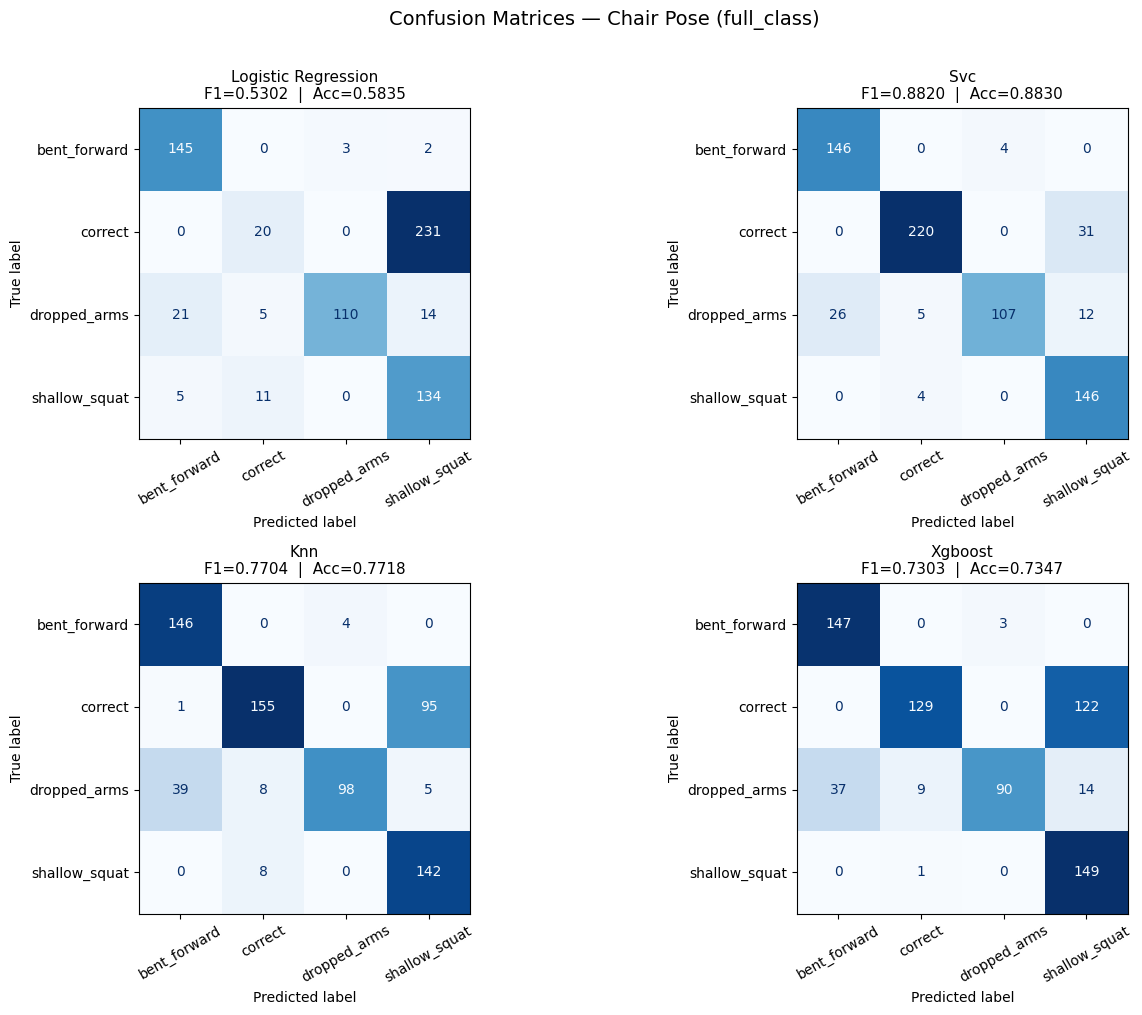

Saved -> chair_pose_files/images/chair_pose_full_class_confusion_matrices.png


In [23]:
#  Confusion matrices - all 4 models 
fig, axes   = plt.subplots(2, 2, figsize=(14, 10))
axes        = axes.flatten()
class_names = list(class_map.values())

for i, result in enumerate(all_results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=class_names,
    )
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(
        f"{result['model'].replace('_', ' ').title()}\n"
        f"F1={result['test_f1_weighted']:.4f}  |  "
        f"Acc={result['test_accuracy']:.4f}",
        fontsize=11,
    )
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle(
    f"Confusion Matrices — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=14, y=1.01,
)
plt.tight_layout()

img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png"
plt.savefig(img_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {OUTPUT_ROOT.name}/images/{img_path.name}")

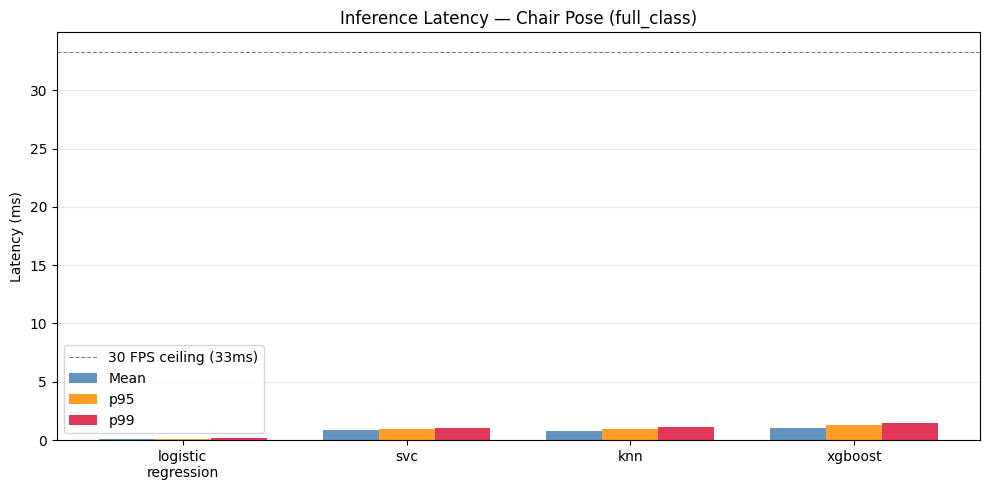

Saved -> chair_pose_files/images/chair_pose_full_class_latency_comparison.png


In [20]:
#  Latency comparison bar chart ─
fig, ax = plt.subplots(figsize=(10, 5))

model_labels = [r["model"].replace("_", "\n") for r in all_results]
mean_vals    = [r["mean_ms"] for r in all_results]
p95_vals     = [r["p95_ms"]  for r in all_results]
p99_vals     = [r["p99_ms"]  for r in all_results]

x     = np.arange(len(model_labels))
width = 0.25

ax.bar(x - width, mean_vals, width, label="Mean", color="steelblue",  alpha=0.85)
ax.bar(x,         p95_vals,  width, label="p95",  color="darkorange", alpha=0.85)
ax.bar(x + width, p99_vals,  width, label="p99",  color="crimson",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel("Latency (ms)")
ax.set_title(
    f"Inference Latency — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})"
)
ax.axhline(y=33.3, color="gray", linestyle="--", linewidth=0.8, label="30 FPS ceiling (33ms)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png"
plt.savefig(img_path, dpi=150)
plt.show()
print(f"Saved -> {OUTPUT_ROOT.name}/images/{img_path.name}")

## GroupKFold Stability Distribution Visual

C:\Users\Acer\AppData\Local\Temp\ipykernel_23172\3439308975.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


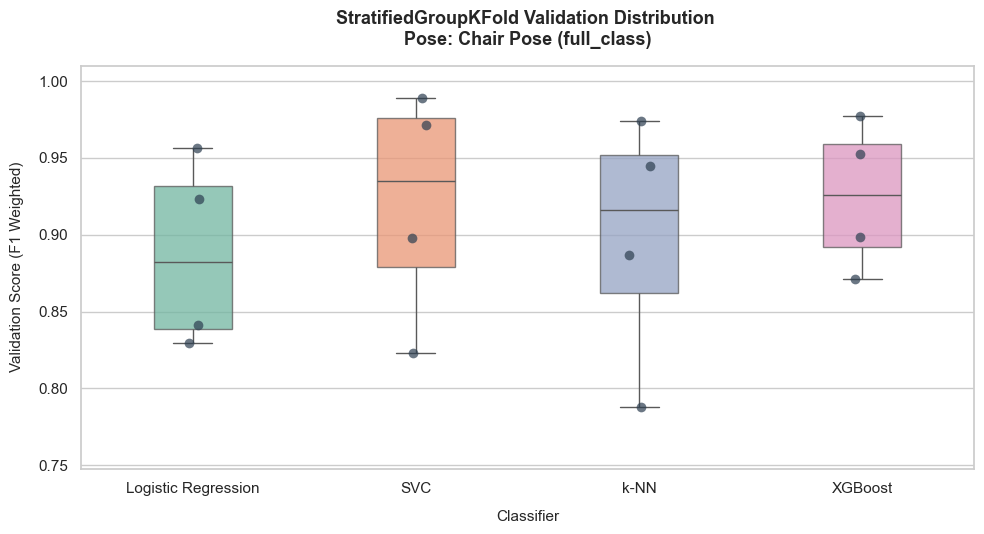

Saved plot to: chair_pose_files/images/chair_pose_full_class_groupkfold_variance.png


In [31]:
# Structure raw data into a DataFrame
cv_box_data = {r["model"]: r["cv_folds_scores"] for r in all_results}
df_cv_box   = pd.DataFrame(cv_box_data)

# Map snake_case model names to formal academic typography
formal_names = {
    "logistic_regression": "Logistic Regression",
    "svc"                : "SVC",
    "knn"                : "k-NN",
    "xgboost"            : "XGBoost"
}
df_cv_box.columns = [formal_names.get(col, col) for col in df_cv_box.columns]

# Melt data for Seaborn processing
df_cv_melted = df_cv_box.melt(var_name='Model', value_name='Cross-Val Score')

# Setup visualization canvas
scoring_name = CV_CONFIG['scoring'].replace('_', ' ').title()
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5.5))

# With ≤3 folds a box is meaningless (only 3 points) — use stripplot + mean line instead
if n_splits_actual <= 3:
    sns.stripplot(
        data    = df_cv_melted,
        x       = 'Model',
        y       = 'Cross-Val Score',
        color   = '#2c3e50',
        alpha   = 0.85,
        size    = 11,
        jitter  = 0.05,
        ax      = ax,
    )
    # Red horizontal mean line per model so the eye has an anchor
    means         = df_cv_melted.groupby('Model')['Cross-Val Score'].mean()
    model_order   = list(df_cv_box.columns)          # preserve column order
    for i, model in enumerate(model_order):
        if model in means:
            ax.hlines(
                means[model], i - 0.2, i + 0.2,
                colors    = 'crimson',
                linewidth = 2.5,
                label     = 'fold mean' if i == 0 else '',
            )
    ax.legend(fontsize=9, loc='lower right')

else:
    # Enough folds for a proper box — draw boxes then overlay individual points
    sns.boxplot(
        data      = df_cv_melted,
        x         = 'Model',
        y         = 'Cross-Val Score',
        palette   = 'Set2',
        width     = 0.35,
        showfliers= False,
        ax        = ax,
        boxprops  = dict(alpha=0.75),
    )
    sns.stripplot(
        data   = df_cv_melted,
        x      = 'Model',
        y      = 'Cross-Val Score',
        color  = '#2c3e50',
        alpha  = 0.7,
        size   = 7,
        jitter = 0.05,
        ax     = ax,
    )

# Shared formatting
ax.set_title(
    f"StratifiedGroupKFold Validation Distribution \n"
    f"Pose: {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize = 13,
    pad      = 15,
    weight   = 'bold',
)
ax.set_ylabel(f"Validation Score ({scoring_name})", fontsize=11, labelpad=10)
ax.set_xlabel("Classifier",                          fontsize=11, labelpad=10)

min_val = df_cv_melted['Cross-Val Score'].min()
ax.set_ylim(max(0.0, min_val - 0.04), 1.01)

plt.tight_layout()

# Save publication-quality artifact
box_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_groupkfold_variance.png"
plt.savefig(box_img_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {OUTPUT_ROOT.name}/images/{box_img_path.name}")

## Diagnostic

In [22]:
# Diagnostic 
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd

sgkf = StratifiedGroupKFold(n_splits=n_splits_actual)

print(f"Total train samples : {len(X_train)}")
print(f"Unique source_ids   : {len(np.unique(groups_train))}")
print()

fold_diagnostics = []

for fold_idx, (tr_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
    val_labels        = y_train[val_idx]
    val_sources       = groups_train[val_idx]
    
    class_counts      = {class_map[k]: int((val_labels == k).sum()) for k in sorted(class_map)}
    n_val_sources     = len(np.unique(val_sources))
    smallest_class    = min(class_counts.values())
    
    fold_diagnostics.append({
        "fold"          : fold_idx,
        "val_samples"   : len(val_idx),
        "val_sources"   : n_val_sources,
        "smallest_class": smallest_class,
        **class_counts,
    })
    
    print(f"Fold {fold_idx}  |  val_samples={len(val_idx)}  |  val_sources={n_val_sources}")
    for cls, cnt in class_counts.items():
        print(f"         {cls:<22}: {cnt}")
    print()

df_folds = pd.DataFrame(fold_diagnostics)
print("Summary:")
print(df_folds)

Total train samples : 2232
Unique source_ids   : 65

Fold 0  |  val_samples=634  |  val_sources=4
         bent_forward          : 150
         correct               : 184
         dropped_arms          : 150
         shallow_squat         : 150

Fold 1  |  val_samples=533  |  val_sources=15
         bent_forward          : 150
         correct               : 83
         dropped_arms          : 150
         shallow_squat         : 150

Fold 2  |  val_samples=533  |  val_sources=22
         bent_forward          : 150
         correct               : 83
         dropped_arms          : 150
         shallow_squat         : 150

Fold 3  |  val_samples=532  |  val_sources=24
         bent_forward          : 150
         correct               : 82
         dropped_arms          : 150
         shallow_squat         : 150

Summary:
   fold  val_samples  val_sources  smallest_class  bent_forward  correct  \
0     0          634            4             150           150      184   
1     1   

In [ ]:
safe_n = None

for n_splits in [3, 4, 5]:
    print(f"\n{'='*40}")
    print(f"Testing n_splits = {n_splits}")
    print(f"{'='*40}")

    sgkf  = StratifiedGroupKFold(n_splits=n_splits)
    clean = True

    for fold_idx, (tr_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups=groups_train)):
        val_labels   = y_train[val_idx]
        class_counts = {class_map[k]: int((val_labels == k).sum()) for k in sorted(class_map)}
        zeros        = [cls for cls, cnt in class_counts.items() if cnt == 0]

        status = "✓" if not zeros else f"✗  ZERO: {zeros}"
        print(f"  Fold {fold_idx}: {class_counts}  {status}")

        if zeros:
            clean = False

    if clean:
        print(f"  --> CLEAN - safe to use")
        # if safe_n is None:
        #     safe_n = n_splits          # record the lowest safe n
        safe_n = n_splits   # keeps overwriting → ends up with the highest clean value

    else:
        print(f"  --> HAS EMPTY FOLDS - do not use")

# Final verdict
print(f"\n{'='*40}")
if safe_n is not None:
    print(f"  RECOMMENDATION: use n_splits = {safe_n} (highest clean value)")
    print(f"  Set CV_CONFIG['n_splits'] = {safe_n}")
else:
    print("  WARNING: no safe n_splits found - even 2-fold has empty class folds.")
    print("  Collect more source_ids for minority classes before running CV.")
print(f"{'='*40}")


Testing n_splits = 3
  Fold 0: {'bent_forward': 300, 'correct': 124, 'dropped_arms': 150, 'shallow_squat': 300}  ✓
  Fold 1: {'bent_forward': 150, 'correct': 124, 'dropped_arms': 300, 'shallow_squat': 150}  ✓
  Fold 2: {'bent_forward': 150, 'correct': 184, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  --> CLEAN — safe to use

Testing n_splits = 4
  Fold 0: {'bent_forward': 150, 'correct': 184, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  Fold 1: {'bent_forward': 150, 'correct': 83, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  Fold 2: {'bent_forward': 150, 'correct': 83, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  Fold 3: {'bent_forward': 150, 'correct': 82, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  --> CLEAN — safe to use

Testing n_splits = 5
  Fold 0: {'bent_forward': 0, 'correct': 184, 'dropped_arms': 0, 'shallow_squat': 150}  ✗  ZERO: ['bent_forward', 'dropped_arms']
  Fold 1: {'bent_forward': 150, 'correct': 62, 'dropped_arms': 150, 'shallow_squat': 150}  ✓
  Fo

## Global Structural Feature Importance Chart

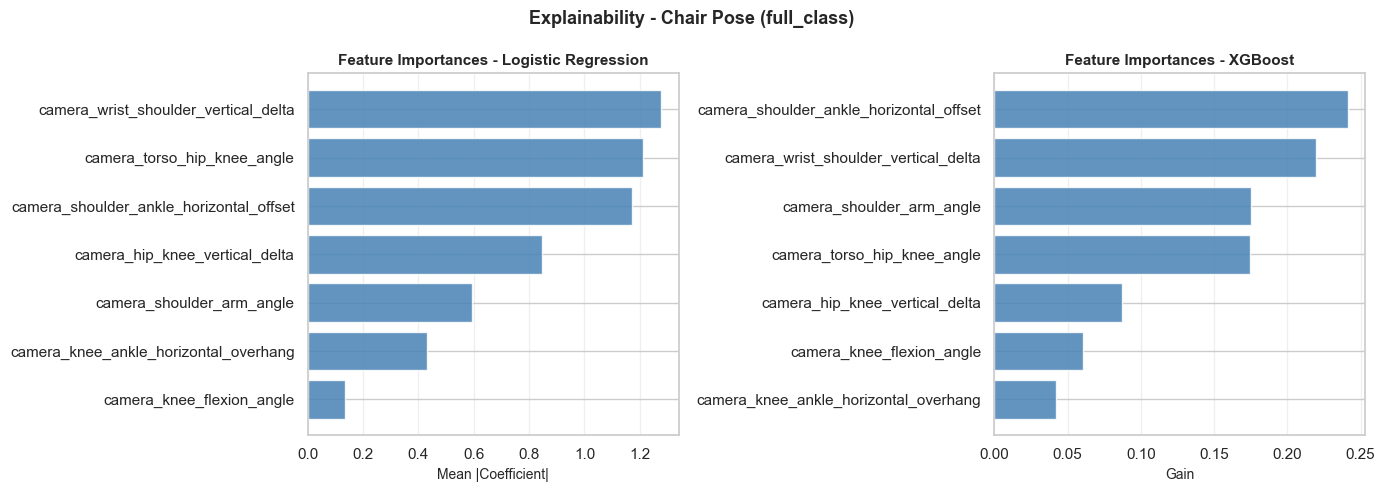

In [25]:
# # Pull out XGBoost or Logistic Regression profile results for explainable AI metrics
# xgb_res = next((item for item in all_results if item["model"] == "xgboost"), None)

# if xgb_res and xgb_res.get("feature_importances") is not None:
#     df_feat = pd.DataFrame({
#         "Feature": FEATURE_COLUMNS,
#         "Relative Importance": xgb_res["feature_importances"]
#     }).sort_values("Relative Importance", ascending=False).head(15) # Top 15 key points
    
#     fig, ax = plt.subplots(figsize=(10, 6))
#     sns.barplot(data=df_feat, x="Relative Importance", y="Feature", palette="flare", ax=ax)
#     ax.set_title(f"Top Spatial Structural Features Driven by XGBoost (Pose Validation)", fontsize=12, pad=12)
#     ax.set_xlabel("Relative Spatial Importance Metric")
#     plt.tight_layout()
    
#     feat_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_feature_importance.png"
#     plt.savefig(feat_img_path, dpi=150)
#     plt.show()
#     print(f"Saved -> {OUTPUT_ROOT.name}/images/{feat_img_path.name}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_models = [r for r in all_results if r["has_feature_importances"]]

for ax, result in zip(axes, importance_models):
    importances = np.array(result["feature_importances"])
    sorted_idx  = np.argsort(importances)

    ax.barh(
        [FEATURE_COLUMNS[i] for i in sorted_idx],
        importances[sorted_idx],
        color="steelblue", alpha=0.85
    )
    formal = {"logistic_regression": "Logistic Regression", "xgboost": "XGBoost"}
    ax.set_title(f"Feature Importances - {formal[result['model']]}", fontsize=11, weight="bold")
    ax.set_xlabel("Mean |Coefficient|" if result["model"] == "logistic_regression" else "Gain", fontsize=10)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    f"Explainability - {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=13, weight="bold"
)
plt.tight_layout()
plt.savefig(DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_feature_importances.png", dpi=300, bbox_inches="tight")
plt.show()

## ONE-VS-REST MULTICLASS ROC CURVES

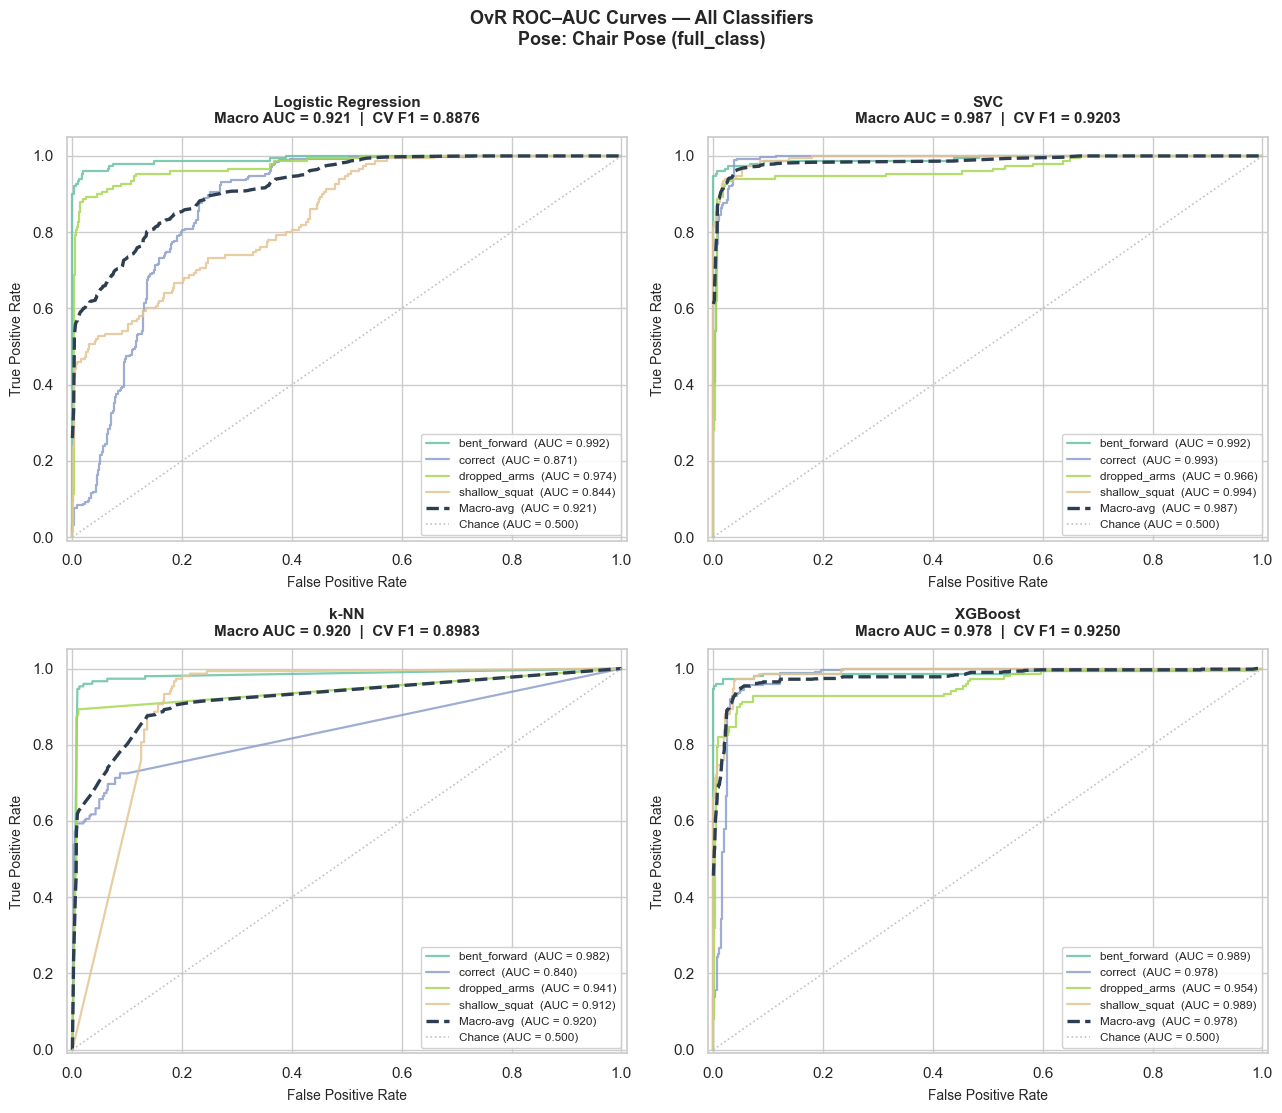

Saved ROC-AUC plot → chair_pose_files/images/chair_pose_full_class_roc_auc_curves.png


In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize ground-truth once
classes      = sorted(class_map.keys())
class_labels = [class_map[c] for c in classes]
n_classes    = len(classes)
y_bin        = label_binarize(y_test, classes=classes)

formal_names = {
    "logistic_regression": "Logistic Regression",
    "svc": "SVC",
    "knn": "k-NN",
    "xgboost": "XGBoost",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
sns.set_theme(style="whitegrid")
axes_flat         = axes.flatten()
per_class_palette = plt.cm.Set2(np.linspace(0, 0.85, n_classes))

for ax_idx, result in enumerate(all_results):
    model_name    = result["model"]
    best_pipeline = best_pipelines[model_name]
    ax            = axes_flat[ax_idx]

    # Probability scores — fall back to decision_function for SVC without probability=True
    if hasattr(best_pipeline, "predict_proba"):
        y_score = best_pipeline.predict_proba(X_test)
    else:
        from sklearn.preprocessing import MinMaxScaler
        y_score = MinMaxScaler().fit_transform(
            best_pipeline.decision_function(X_test)
        )

    # Per-class ROC
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i]        = auc(fpr[i], tpr[i])

    # Macro average
    all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.mean([np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_classes)], axis=0)
    macro_auc = auc(all_fpr, mean_tpr)

    # Plot per-class curves
    for i, label in enumerate(class_labels):
        ax.plot(fpr[i], tpr[i], color=per_class_palette[i], lw=1.6, alpha=0.85,
                label=f"{label}  (AUC = {roc_auc[i]:.3f})")

    # Macro average + chance diagonal
    ax.plot(all_fpr, mean_tpr, color="#2c3e50", lw=2.4, linestyle="--",
            label=f"Macro-avg  (AUC = {macro_auc:.3f})")
    ax.plot([0, 1], [0, 1], color="#bdc3c7", lw=1.2, linestyle=":",
            label="Chance (AUC = 0.500)")

    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=10, labelpad=6)
    ax.set_ylabel("True Positive Rate", fontsize=10, labelpad=6)
    ax.set_title(
        f"{formal_names.get(model_name, model_name)}\n"
        f"Macro AUC = {macro_auc:.3f}  |  CV F1 = {result['best_cv_score']:.4f}",
        fontsize=11, weight="bold", pad=10,
    )
    ax.legend(fontsize=8.5, loc="lower right", framealpha=0.9)

fig.suptitle(
    f"OvR ROC–AUC Curves — All Classifiers\n"
    f"Pose: {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=13, weight="bold", y=1.01,
)
plt.tight_layout()

roc_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_roc_auc_curves.png"
plt.savefig(roc_img_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved ROC-AUC plot → {OUTPUT_ROOT.name}/images/{roc_img_path.name}")

## 9. Artifact Verification

In [32]:
#  Confirm all expected artifacts were written to disk ─
expected_files = []
for model_name in MODELS:
    prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"
    expected_files += [
        (DIR_MODELS    / f"{prefix}_pipeline.joblib"),
        (DIR_MODELS    / f"{prefix}_label_encoder.joblib"),
        (DIR_METADATA  / f"{prefix}_class_map.json"),
        (DIR_METADATA  / f"{prefix}_metadata.json"),
    ]

expected_files += [
    DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png",
]

all_ok = True
for fpath in expected_files:
    exists  = fpath.exists()
    status  = "OK"      if exists else "MISSING"
    folder  = fpath.parent.name
    if not exists:
        all_ok = False
    print(f"  [{status}]  {folder}/{fpath.name}")

print()
print("All artifacts present." if all_ok else "WARNING: Some artifacts are missing.")

  [OK]  models/chair_pose_full_class_logistic_regression_pipeline.joblib
  [OK]  models/chair_pose_full_class_logistic_regression_label_encoder.joblib
  [OK]  metadata/chair_pose_full_class_logistic_regression_class_map.json
  [OK]  metadata/chair_pose_full_class_logistic_regression_metadata.json
  [OK]  models/chair_pose_full_class_svc_pipeline.joblib
  [OK]  models/chair_pose_full_class_svc_label_encoder.joblib
  [OK]  metadata/chair_pose_full_class_svc_class_map.json
  [OK]  metadata/chair_pose_full_class_svc_metadata.json
  [OK]  models/chair_pose_full_class_knn_pipeline.joblib
  [OK]  models/chair_pose_full_class_knn_label_encoder.joblib
  [OK]  metadata/chair_pose_full_class_knn_class_map.json
  [OK]  metadata/chair_pose_full_class_knn_metadata.json
  [OK]  models/chair_pose_full_class_xgboost_pipeline.joblib
  [OK]  models/chair_pose_full_class_xgboost_label_encoder.joblib
  [OK]  metadata/chair_pose_full_class_xgboost_class_map.json
  [OK]  metadata/chair_pose_full_class_xgboos

## 10. Inference Smoke-Test

Loads the saved artifacts for the **best-performing model** and runs a
prediction on a single sample — exactly replicating what the real-video
inference script will do.

This verifies the full round-trip:
`raw features → load pipeline → predict → decode label`


In [66]:
# #  Pick the best model by test F1 
# best_model_name = results_df.iloc[0]["model"]

# prefix = (
#     f"{POSE_NAME}_{experiment_tag}_{best_model_name}"
# )

# print(
#     f"Best model: {best_model_name} "
#     f"(F1={results_df.iloc[0]['test_f1_weighted']:.4f})"
# )
# print()

# #  Load artifacts from disk ─
# loaded_pipeline = joblib.load(
#     DIR_MODELS / f"{prefix}_pipeline.joblib"
# )

# loaded_encoder = joblib.load(
#     DIR_MODELS / f"{prefix}_label_encoder.joblib"
# )

# with open(
#     DIR_METADATA / f"{prefix}_class_map.json",
#     "r"
# ) as f:
#     loaded_class_map = json.load(f)

# with open(
#     DIR_METADATA / f"{prefix}_metadata.json",
#     "r"
# ) as f:
#     loaded_metadata = json.load(f)

# print("Loaded artifacts:")
# print(f"  Pipeline       : {loaded_pipeline}")
# print(f"  Label encoder  : classes = {list(loaded_encoder.classes_)}")
# print(f"  Feature columns: {loaded_metadata['feature_columns']}")
# print()

# #  Run a prediction on one test sample ─
# # In real-video inference: replace this with MediaPipe-extracted features

# sample_features = X_test[0:1]   # shape (1, n_features)

# raw_pred = loaded_pipeline.predict(sample_features)

# decoded_label = loaded_encoder.inverse_transform(raw_pred)[0]

# true_label = loaded_encoder.inverse_transform([y_test[0]])[0]

# print(f"Sample features  : {sample_features[0]}")
# print(f"Predicted (int)  : {raw_pred[0]}")
# print(f"Predicted (label): '{decoded_label}'")
# print(f"True label       : '{true_label}'")
# print()

# print(
#     "Smoke-test passed."
#     if decoded_label is not None
#     else "Smoke-test FAILED."
# )